In [1]:
!pip install -q huggingface_hub
from huggingface_hub import login
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(
    repo_id="HAEEAI/multi-person-localization",
    repo_type="dataset"
)

print("Dataset path:", dataset_path)

Fetching 29 files:   0%|          | 0/29 [00:00<?, ?it/s]

Dataset path: /root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df


In [3]:
import os

npz_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith(".npz"):
            npz_files.append(os.path.join(root, f))

npz_files = sorted(npz_files)
print("Total .npz files:", len(npz_files))
print("First 5 files:")
for f in npz_files[:5]:
    print(f)

Total .npz files: 24
First 5 files:
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000000.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000001.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000002.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000003.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000004.npz


In [4]:
import numpy as np

sample_file = npz_files[0]
data = np.load(sample_file)

radar = data["radar_cir_iq"]      # shape: (T, 6, 3, 120, 2)
people_xy = data["people_xy"]     # shape: (T, 4, 2)
people_mask = data["people_mask"] # shape: (T, 4)
timestamps = data["timestamps"]   # shape: (T,)

print("radar shape:", radar.shape)
print("people_xy shape:", people_xy.shape)
print("people_mask shape:", people_mask.shape)
print("timestamps shape:", timestamps.shape)

radar shape: (7500, 6, 3, 120, 2)
people_xy shape: (7500, 4, 2)
people_mask shape: (7500, 4)
timestamps shape: (7500,)


In [5]:
def iq_to_magnitude(radar_iq):
    """
    radar_iq: (T, 6, 3, 120, 2)
    returns:  (T, 6, 3, 120)
    """
    I = radar_iq[..., 0]
    Q = radar_iq[..., 1]
    mag = np.sqrt(I**2 + Q**2)
    return mag.astype(np.float32)

mag = iq_to_magnitude(radar)
print("Magnitude shape:", mag.shape)

Magnitude shape: (7500, 6, 3, 120)


In [6]:
def magnitude_to_18ch_images(mag):
    """
    mag: (T, 6, 3, 120)
    returns: (T, 120, 18)

    Each frame becomes a matrix of shape (120, 18):
    - 120 rows = bins
    - 18 columns/channels = 6 radars * 3 antennas
    """
    T = mag.shape[0]

    # move bins before radar and antenna
    x = mag.transpose(0, 3, 1, 2)   # (T, 120, 6, 3)

    # flatten radar and antenna into one channel axis
    x = x.reshape(T, 120, 18)       # (T, 120, 18)

    return x.astype(np.float32)

images_18ch = magnitude_to_18ch_images(mag)
print("18-channel representation:", images_18ch.shape)

18-channel representation: (7500, 120, 18)


In [7]:
frame_idx = 0
frame_img = images_18ch[frame_idx]

print("One frame shape:", frame_img.shape)   # (120, 18)
print(frame_img[:5, :5])  # small preview

One frame shape: (120, 18)
[[6.7082038e+00 1.9235384e+01 3.0610456e+01 8.9442720e+00 1.8384777e+01]
 [3.1780497e+01 4.1914438e+02 8.4467743e+02 5.8000000e+01 4.7244577e+02]
 [2.2600885e+02 3.4828628e+03 6.7073818e+03 6.2445013e+02 4.0255764e+03]
 [7.8390051e+02 1.1191248e+04 1.9278912e+04 1.8892605e+03 1.3162456e+04]
 [2.7239927e+03 1.7842049e+04 2.4128881e+04 1.1263615e+03 2.1597266e+04]]


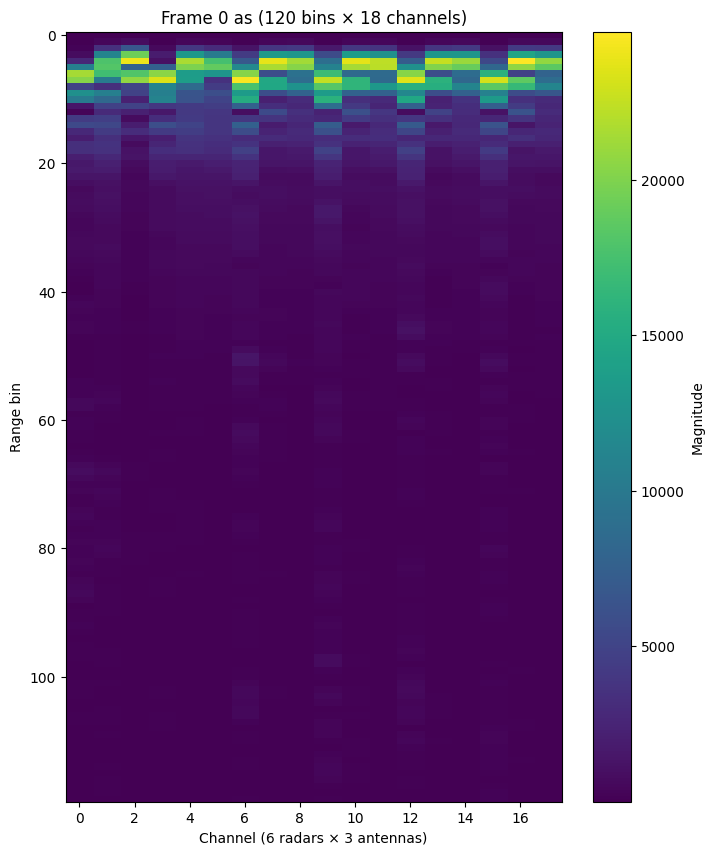

In [8]:
import matplotlib.pyplot as plt

frame_idx = 0

plt.figure(figsize=(8, 10))
plt.imshow(images_18ch[frame_idx], aspect='auto', cmap='viridis')
plt.title(f"Frame {frame_idx} as (120 bins × 18 channels)")
plt.xlabel("Channel (6 radars × 3 antennas)")
plt.ylabel("Range bin")
plt.colorbar(label="Magnitude")
plt.show()

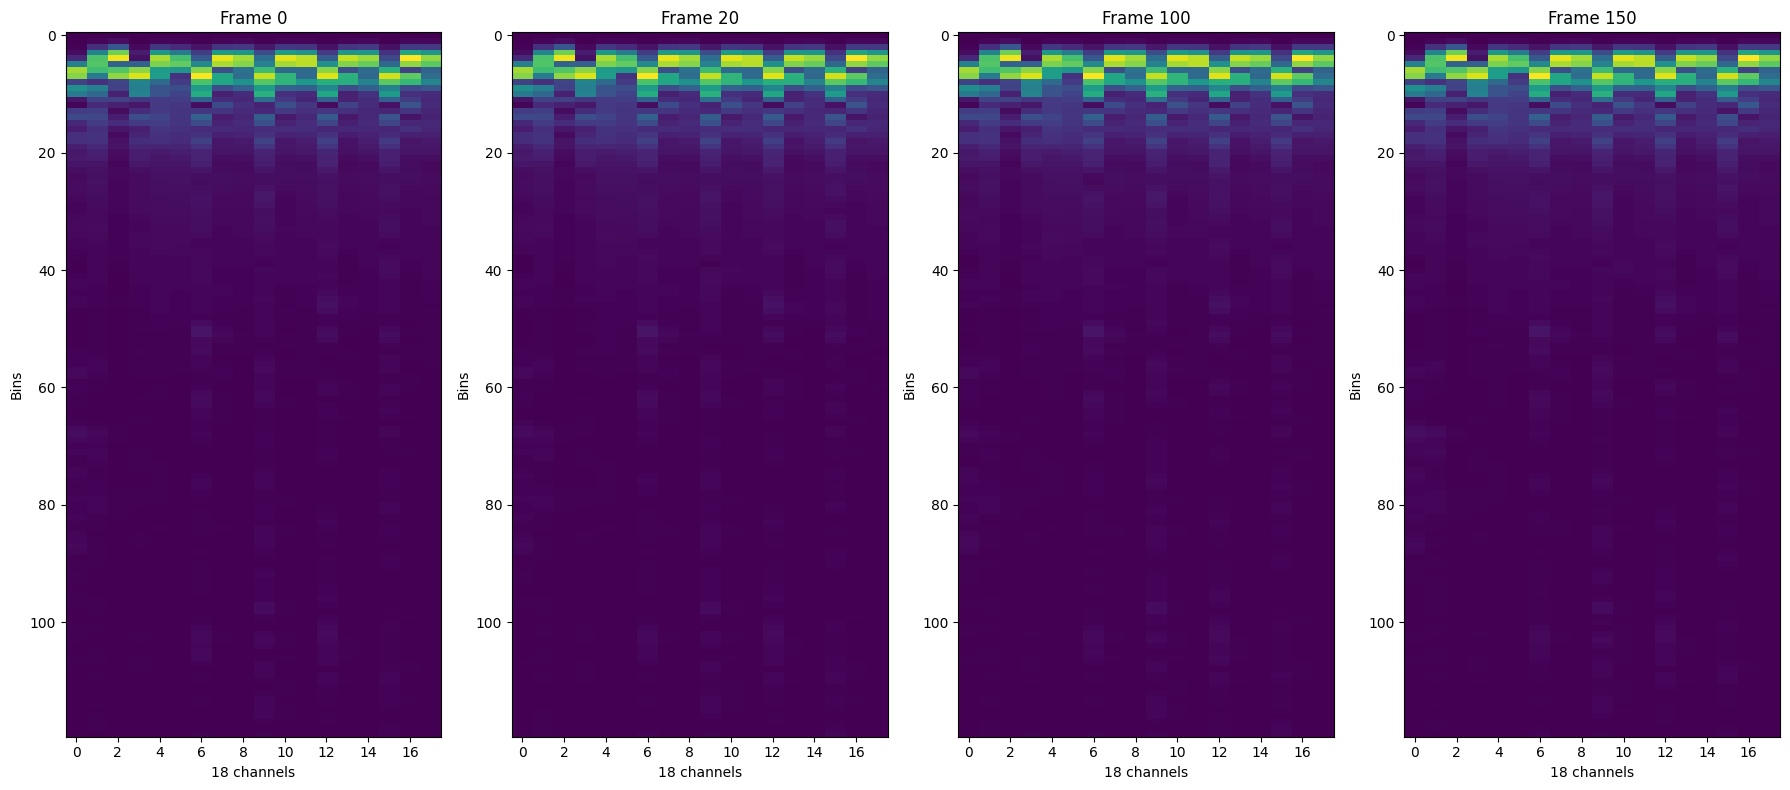

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 8))

for i, fidx in enumerate([0, 20, 100, 150]):
    axes[i].imshow(images_18ch[fidx], aspect='auto', cmap='viridis')
    axes[i].set_title(f"Frame {fidx}")
    axes[i].set_xlabel("18 channels")
    axes[i].set_ylabel("Bins")

plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def animate_frames_colab(images_18ch, start=0, end=200, interval=50):
    fig, ax = plt.subplots(figsize=(6, 8))

    im = ax.imshow(images_18ch[start], aspect='auto', cmap='viridis')
    ax.set_xlabel("Channels (18)")
    ax.set_ylabel("Range bins")

    def update(frame):
        im.set_array(images_18ch[frame])
        ax.set_title(f"Frame {frame}")
        return [im]

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=range(start, end),
        interval=interval,
        blit=True
    )

    plt.close(fig)  # IMPORTANT: prevents duplicate static plot

    return HTML(ani.to_jshtml())

In [11]:
images_log = np.log1p(images_18ch)

animate_frames_colab(images_log, start=0, end=200, interval=50)

In [12]:
# =========================
# Sensor / channel selection
# =========================

# Whole sensors to include
# Each sensor contributes 3 channels:
# sensor 0 -> [0,1,2]
# sensor 1 -> [3,4,5]
# sensor 2 -> [6,7,8]
# sensor 3 -> [9,10,11]
# sensor 4 -> [12,13,14]
# sensor 5 -> [15,16,17]
SELECTED_SENSORS = [0]   # example: use just one sensor

# Extra individual channels to include manually
# Leave empty if you only want full sensors
SELECTED_CHANNELS = []   # example: [0, 1, 2, 9, 10]

# If both are provided, the final used channels are the union of both

In [13]:
def sensor_to_channels(sensor_id):
    """Map sensor id -> 3 flattened channel ids."""
    base = sensor_id * 3
    return [base, base + 1, base + 2]

def resolve_selected_channels(selected_sensors, selected_channels):
    """
    Build final sorted unique flattened channel list.
    """
    final_channels = []

    # add all channels from selected sensors
    for s in selected_sensors:
        if s < 0 or s > 5:
            raise ValueError(f"Invalid sensor id {s}. Must be in [0..5].")
        final_channels.extend(sensor_to_channels(s))

    # add manually selected channels
    for ch in selected_channels:
        if ch < 0 or ch > 17:
            raise ValueError(f"Invalid channel id {ch}. Must be in [0..17].")
        final_channels.append(ch)

    final_channels = sorted(set(final_channels))

    if len(final_channels) == 0:
        raise ValueError("No channels selected. Set SELECTED_SENSORS and/or SELECTED_CHANNELS.")

    return final_channels

FINAL_SELECTED_CHANNELS = resolve_selected_channels(SELECTED_SENSORS, SELECTED_CHANNELS)

print("Selected sensors :", SELECTED_SENSORS)
print("Selected channels:", SELECTED_CHANNELS)
print("Final channels   :", FINAL_SELECTED_CHANNELS)
print("Num channels     :", len(FINAL_SELECTED_CHANNELS))

Selected sensors : [0]
Selected channels: []
Final channels   : [0, 1, 2]
Num channels     : 3


In [270]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

# =========================
# Config
# =========================
SEQ_LEN = 16
FRAME_STRIDE = 10
USE_LOG = True
TEST_SIZE = 0.25
RANDOM_STATE = 42
ONLY_ONE_PERSON = True

# Decluttering / preprocessing
DECLUTTER_MODE = "mean"   # "mean" or "ema"
EMA_ALPHA = 0.98          # only used if DECLUTTER_MODE == "ema"

USE_MAG = False
USE_DECLUTTERED_MAG = False
USE_MOTION_MAG = True
USE_PHASE_DIFF = False

# Optional bin cropping to remove useless near/far bins
BIN_START = 0
BIN_END = 120   # e.g. try 5:80 later

ROOM_X = 4.8
ROOM_Y = 7.2
MAX_PEOPLE = 4

# =========================
# Sensor / channel selection
# =========================
# sensor 0 -> channels [0,1,2]
# sensor 1 -> channels [3,4,5]
# sensor 2 -> channels [6,7,8]
# sensor 3 -> channels [9,10,11]
# sensor 4 -> channels [12,13,14]
# sensor 5 -> channels [15,16,17]

SELECTED_SENSORS = [0,1,2,3,4,5]      # example: use only sensor 0
SELECTED_CHANNELS = []      # optional extra manual channels


def sensor_to_channels(sensor_id):
    base = sensor_id * 3
    return [base, base + 1, base + 2]


def resolve_selected_channels(selected_sensors, selected_channels):
    final_channels = []

    for s in selected_sensors:
        if s < 0 or s > 5:
            raise ValueError(f"Invalid sensor id {s}. Must be in [0..5].")
        final_channels.extend(sensor_to_channels(s))

    for ch in selected_channels:
        if ch < 0 or ch > 17:
            raise ValueError(f"Invalid channel id {ch}. Must be in [0..17].")
        final_channels.append(ch)

    final_channels = sorted(set(final_channels))

    if len(final_channels) == 0:
        raise ValueError("No channels selected. Set SELECTED_SENSORS and/or SELECTED_CHANNELS.")

    return final_channels


FINAL_SELECTED_CHANNELS = resolve_selected_channels(
    SELECTED_SENSORS,
    SELECTED_CHANNELS
)

print("Selected sensors :", SELECTED_SENSORS)
print("Selected channels:", SELECTED_CHANNELS)
print("Final channels   :", FINAL_SELECTED_CHANNELS)

# =========================
# Find all windows
# =========================
npz_files = []
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith(".npz"):
            npz_files.append(os.path.join(root, f))

npz_files = sorted(npz_files)

print("Total windows:", len(npz_files))
for f in npz_files[:5]:
    print(f)

# =========================
# Helpers
# =========================
def build_complex_cir(radar_iq):
    """
    radar_iq: (T, 6, 3, 120, 2)
    return:   complex array (T, 6, 3, 120)
    """
    I = radar_iq[..., 0]
    Q = radar_iq[..., 1]
    z = I + 1j * Q
    return z.astype(np.complex64)


def declutter_mean(x):
    """
    x: (T, B, C)
    subtract temporal mean from each bin/channel
    """
    return x - x.mean(axis=0, keepdims=True)


def declutter_ema(x, alpha=0.98):
    """
    x: (T, B, C)
    exponential moving average background subtraction
    """
    out = np.zeros_like(x, dtype=np.float32)
    bg = x[0].copy()

    for t in range(x.shape[0]):
        bg = alpha * bg + (1.0 - alpha) * x[t]
        out[t] = x[t] - bg

    return out


def apply_declutter(x, mode="mean", alpha=0.98):
    if mode == "mean":
        return declutter_mean(x)
    elif mode == "ema":
        return declutter_ema(x, alpha=alpha)
    else:
        raise ValueError(f"Unknown declutter mode: {mode}")


def build_radar_features(
    radar_iq,
    selected_channels,
    use_log=True,
    declutter_mode="mean",
    ema_alpha=0.98,
    use_mag=False,
    use_decluttered_mag=True,
    use_motion_mag=True,
    use_phase_diff=True,
    bin_start=0,
    bin_end=120
):
    """
    radar_iq: (T, 6, 3, 120, 2)
    selected_channels: flattened ids in [0..17]

    Returns:
      feats: (T, B_used, C_feat)

    Feature blocks:
      1) log-magnitude
      2) decluttered magnitude
      3) motion magnitude
      4) phase-difference over time
    """
    # complex CIR
    z = build_complex_cir(radar_iq)   # (T, 6, 3, 120)

    # magnitude
    mag = np.abs(z).astype(np.float32)  # (T, 6, 3, 120)
    if use_log:
        mag = np.log1p(mag)

    # flatten channels -> (T, 120, 18)
    mag = mag.transpose(0, 3, 1, 2).reshape(mag.shape[0], 120, 18)
    mag = mag[:, :, selected_channels]  # (T, 120, C)

    feature_blocks = []

    # 1) base magnitude
    if use_mag:
        feature_blocks.append(mag)

    # 2) decluttered magnitude
    if use_decluttered_mag or use_motion_mag:
        mag_dc = apply_declutter(mag, mode=declutter_mode, alpha=ema_alpha)
    else:
        mag_dc = None

    if use_decluttered_mag:
        feature_blocks.append(mag_dc)

    # 3) motion magnitude
    if use_motion_mag:
        motion_mag = np.diff(mag_dc, axis=0, prepend=mag_dc[:1])
        motion_mag = np.abs(motion_mag)
        feature_blocks.append(motion_mag.astype(np.float32))

    # 4) phase difference over time
    if use_phase_diff:
        # phase difference from complex ratio between consecutive frames
        phase_diff = np.angle(z[1:] * np.conj(z[:-1]))  # (T-1, 6, 3, 120)

        # pad first frame
        phase_diff = np.concatenate(
            [np.zeros_like(phase_diff[:1]), phase_diff],
            axis=0
        )  # (T, 6, 3, 120)

        phase_diff = phase_diff.astype(np.float32)
        phase_diff = phase_diff.transpose(0, 3, 1, 2).reshape(phase_diff.shape[0], 120, 18)
        phase_diff = phase_diff[:, :, selected_channels]

        feature_blocks.append(phase_diff)

    feats = np.concatenate(feature_blocks, axis=2)  # (T, 120, C_feat)

    # optional bin crop
    feats = feats[:, bin_start:bin_end, :]

    return feats.astype(np.float32)


def sort_people_by_x(xy, mask):
    valid = mask.astype(bool)
    xy_valid = xy[valid]

    if len(xy_valid) > 0:
        order = np.argsort(xy_valid[:, 0])
        xy_valid = xy_valid[order]

    xy_out = np.zeros((MAX_PEOPLE, 2), dtype=np.float32)
    mask_out = np.zeros((MAX_PEOPLE,), dtype=np.float32)

    n = min(len(xy_valid), MAX_PEOPLE)
    if n > 0:
        xy_out[:n] = xy_valid[:n]
        mask_out[:n] = 1.0

    return xy_out, mask_out


def build_samples_from_window(
    npz_path,
    seq_len=12,
    frame_stride=8
):
    """
    Returns:
      X_seq      : (N, seq_len, B_used, C_feat)
      y_xy       : (N, 4, 2)
      y_mask     : (N, 4)
      meta_frame : (N,)
    """
    d = np.load(npz_path)

    radar = d["radar_cir_iq"].astype(np.float32)
    people_xy = d["people_xy"].astype(np.float32)
    people_mask = d["people_mask"].astype(np.float32)

    feats = build_radar_features(
        radar,
        selected_channels=FINAL_SELECTED_CHANNELS,
        use_log=USE_LOG,
        declutter_mode=DECLUTTER_MODE,
        ema_alpha=EMA_ALPHA,
        use_mag=USE_MAG,
        use_decluttered_mag=USE_DECLUTTERED_MAG,
        use_motion_mag=USE_MOTION_MAG,
        use_phase_diff=USE_PHASE_DIFF,
        bin_start=BIN_START,
        bin_end=BIN_END
    )

    X_list, y_xy_list, y_mask_list, frame_idx_list = [], [], [], []

    T = feats.shape[0]

    for end_frame in range(seq_len - 1, T, frame_stride):

        # =========================
        # Keep only 1-person samples
        # =========================
        if ONLY_ONE_PERSON:
            if int(people_mask[end_frame].sum()) != 1:
                continue

        seq = feats[end_frame - seq_len + 1 : end_frame + 1]

        xy, m = sort_people_by_x(
            people_xy[end_frame],
            people_mask[end_frame]
        )

        X_list.append(seq)
        y_xy_list.append(xy)
        y_mask_list.append(m)
        frame_idx_list.append(end_frame)


    C_feat = feats.shape[-1]
    B_used = feats.shape[1]

    if len(X_list) == 0:
        X_seq = np.empty((0, seq_len, B_used, C_feat), dtype=np.float32)
        y_xy = np.empty((0, MAX_PEOPLE, 2), dtype=np.float32)
        y_mask = np.empty((0, MAX_PEOPLE), dtype=np.float32)
        meta_frame = np.empty((0,), dtype=np.int32)
        return X_seq, y_xy, y_mask, meta_frame

    X_seq = np.stack(X_list).astype(np.float32)
    y_xy = np.stack(y_xy_list).astype(np.float32)
    y_mask = np.stack(y_mask_list).astype(np.float32)
    meta_frame = np.array(frame_idx_list, dtype=np.int32)

    return X_seq, y_xy, y_mask, meta_frame

    X_seq = np.stack(X_list).astype(np.float32)
    y_xy = np.stack(y_xy_list).astype(np.float32)
    y_mask = np.stack(y_mask_list).astype(np.float32)
    meta_frame = np.array(frame_idx_list, dtype=np.int32)

    return X_seq, y_xy, y_mask, meta_frame


# =========================
# Train/test split by window
# =========================
train_files, test_files = train_test_split(
    npz_files,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("\nTrain windows:", len(train_files))
print("Test windows :", len(test_files))

print("\nExample train windows:")
for f in train_files[:3]:
    print(" ", os.path.basename(f))

print("\nExample test windows:")
for f in test_files[:3]:
    print(" ", os.path.basename(f))

# =========================
# Build full train set
# =========================
X_train_list = []
y_xy_train_list = []
y_mask_train_list = []
train_window_name_list = []
train_frame_idx_list = []

for f in train_files:
    X_seq, y_xy, y_mask, meta_frame = build_samples_from_window(
        f,
        seq_len=SEQ_LEN,
        frame_stride=FRAME_STRIDE
    )

    if len(X_seq) == 0:
        continue

    X_train_list.append(X_seq)
    y_xy_train_list.append(y_xy)
    y_mask_train_list.append(y_mask)

    train_window_name_list.extend([os.path.basename(f)] * len(X_seq))
    train_frame_idx_list.append(meta_frame)

X_train = np.concatenate(X_train_list, axis=0)
y_xy_train = np.concatenate(y_xy_train_list, axis=0)
y_mask_train = np.concatenate(y_mask_train_list, axis=0)
train_frame_idx = np.concatenate(train_frame_idx_list, axis=0)
train_window_name = np.array(train_window_name_list)

# =========================
# Build full test set
# =========================
X_test_list = []
y_xy_test_list = []
y_mask_test_list = []
test_window_name_list = []
test_frame_idx_list = []

for f in test_files:
    X_seq, y_xy, y_mask, meta_frame = build_samples_from_window(
        f,
        seq_len=SEQ_LEN,
        frame_stride=FRAME_STRIDE
    )

    X_test_list.append(X_seq)
    y_xy_test_list.append(y_xy)
    y_mask_test_list.append(y_mask)

    test_window_name_list.extend([os.path.basename(f)] * len(X_seq))
    test_frame_idx_list.append(meta_frame)

X_test = np.concatenate(X_test_list, axis=0)
y_xy_test = np.concatenate(y_xy_test_list, axis=0)
y_mask_test = np.concatenate(y_mask_test_list, axis=0)
test_frame_idx = np.concatenate(test_frame_idx_list, axis=0)
test_window_name = np.array(test_window_name_list)

# =========================
# Normalize using train stats only
# =========================
mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
std = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-6

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# =========================
# Print summary
# =========================
print("\n===== Final Shapes =====")
print("X_train     :", X_train.shape)
print("y_xy_train  :", y_xy_train.shape)
print("y_mask_train:", y_mask_train.shape)

print("X_test      :", X_test.shape)
print("y_xy_test   :", y_xy_test.shape)
print("y_mask_test :", y_mask_test.shape)

print("\nTrain sample example:")
print("window:", train_window_name[0])
print("frame :", train_frame_idx[0])
print("input shape:", X_train[0].shape)
print("xy label:\n", y_xy_train[0])
print("mask label:", y_mask_train[0])

# =========================
# Optional: save prepared arrays
# =========================
np.save("X_train.npy", X_train)
np.save("y_xy_train.npy", y_xy_train)
np.save("y_mask_train.npy", y_mask_train)

np.save("X_test.npy", X_test)
np.save("y_xy_test.npy", y_xy_test)
np.save("y_mask_test.npy", y_mask_test)

print("\nSaved prepared arrays to current Colab working directory.")

Selected sensors : [0, 1, 2, 3, 4, 5]
Selected channels: []
Final channels   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Total windows: 24
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000000.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000001.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000002.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000003.npz
/root/.cache/huggingface/hub/datasets--HAEEAI--multi-person-localization/snapshots/265b3e54e10e109122a2539e400abfeb6d5f05df/data/window_000004.npz

Train windows: 18
Test windows : 6

Example train windows:
  window_000013.npz
  window_000001.npz
  win

In [271]:
import matplotlib.pyplot as plt

def show_processed_sample(X, sample_idx=0, num_selected_channels=3):
    """
    Assumes feature order:
      [mag | decluttered_mag | motion_mag | phase_diff]
    with each block having num_selected_channels channels.
    """
    sample = X[sample_idx]   # (SEQ_LEN, B_used, C_feat)

    c = num_selected_channels

    idx0 = 0
    idx1 = c
    idx2 = 2 * c
    idx3 = 3 * c

    mag = sample[:, :, idx0:idx1]
    mag_dc = sample[:, :, idx1:idx2]
    motion = sample[:, :, idx2:idx3]
    phase_diff = sample[:, :, idx3:idx3 + c]

    fig, axes = plt.subplots(4, c, figsize=(4 * c, 12), squeeze=False)

    for ch in range(c):
        axes[0, ch].imshow(mag[:, :, ch], aspect="auto", cmap="magma")
        axes[0, ch].set_title(f"log-mag ch {ch}")
        axes[0, ch].set_xlabel("Bins")
        axes[0, ch].set_ylabel("Time")

        axes[1, ch].imshow(mag_dc[:, :, ch], aspect="auto", cmap="magma")
        axes[1, ch].set_title(f"decluttered ch {ch}")
        axes[1, ch].set_xlabel("Bins")
        axes[1, ch].set_ylabel("Time")

        axes[2, ch].imshow(motion[:, :, ch], aspect="auto", cmap="magma")
        axes[2, ch].set_title(f"motion ch {ch}")
        axes[2, ch].set_xlabel("Bins")
        axes[2, ch].set_ylabel("Time")

        axes[3, ch].imshow(phase_diff[:, :, ch], aspect="auto", cmap="twilight")
        axes[3, ch].set_title(f"phase-diff ch {ch}")
        axes[3, ch].set_xlabel("Bins")
        axes[3, ch].set_ylabel("Time")

    plt.tight_layout()
    plt.show()

In [251]:
num_selected_channels=len(FINAL_SELECTED_CHANNELS)

IndexError: index 0 is out of bounds for axis 2 with size 0

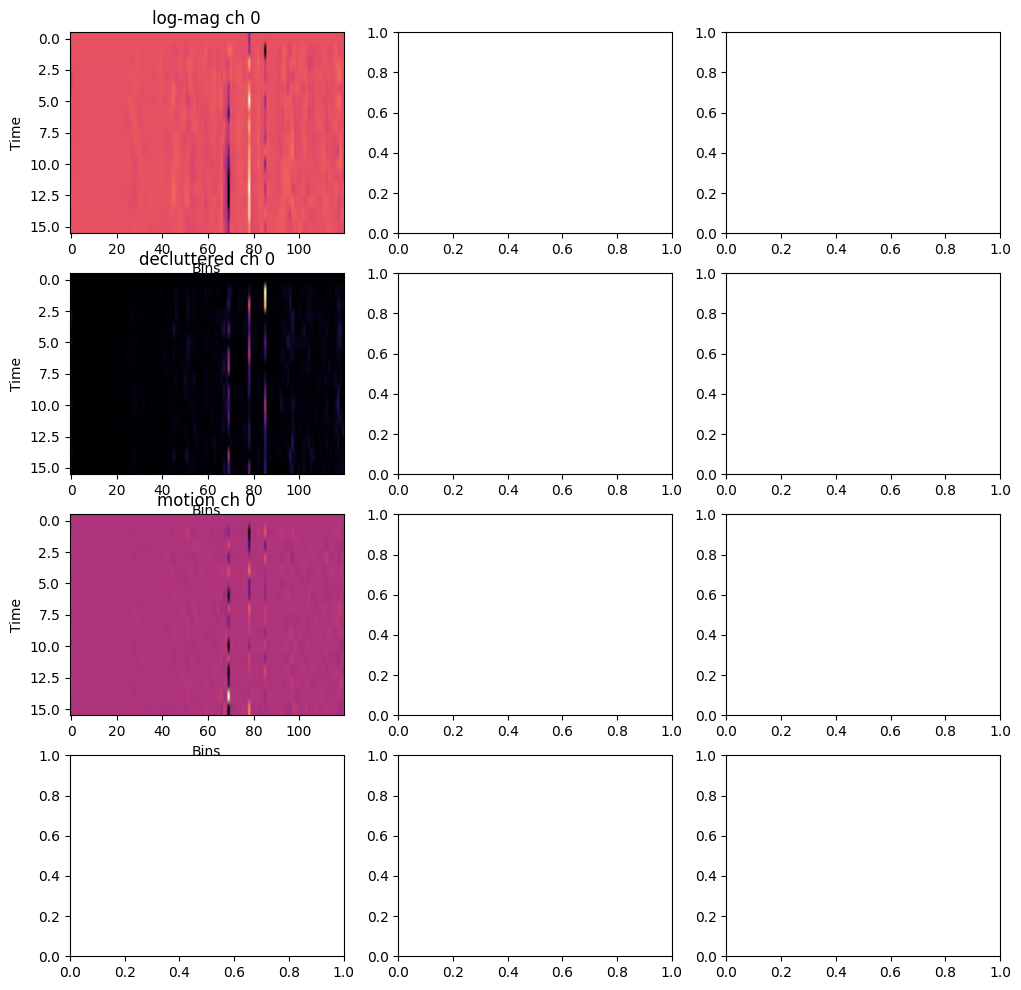

In [230]:
show_processed_sample(X_train, sample_idx=0,num_selected_channels=num_selected_channels )

In [252]:
import numpy as np

ROOM_X = 4.8
ROOM_Y = 7.2

HEATMAP_H = 48
HEATMAP_W = 32

def make_heatmap_from_points(xy, mask, H=24, W=16, room_x=4.8, room_y=7.2, sigma=1.0):
    """
    xy:   (4, 2)
    mask: (4,)
    return: (H, W, 1)
    """
    heatmap = np.zeros((H, W), dtype=np.float32)

    ys = np.arange(H, dtype=np.float32)
    xs = np.arange(W, dtype=np.float32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")  # (H, W)

    for i in range(len(mask)):
        if mask[i] < 0.5:
            continue

        px, py = xy[i]

        # clamp to room just in case
        px = np.clip(px, 0.0, room_x)
        py = np.clip(py, 0.0, room_y)

        # convert meters -> heatmap pixel coordinates
        col = (px / room_x) * (W - 1)
        row = (py / room_y) * (H - 1)

        g = np.exp(-((xx - col) ** 2 + (yy - row) ** 2) / (2 * sigma ** 2))
        heatmap = np.maximum(heatmap, g)

    return heatmap[..., None]  # (H, W, 1)


def build_heatmaps(y_xy, y_mask, H=24, W=16, sigma=1.0):
    heatmaps = [
        make_heatmap_from_points(
            y_xy[i], y_mask[i],
            H=H, W=W,
            room_x=ROOM_X, room_y=ROOM_Y,
            sigma=sigma
        )
        for i in range(len(y_xy))
    ]
    return np.stack(heatmaps).astype(np.float32)

In [253]:
y_heat_train = build_heatmaps(y_xy_train, y_mask_train, H=48, W=32, sigma=0.75)
y_heat_test  = build_heatmaps(y_xy_test,  y_mask_test,  H=48, W=32, sigma=0.75)

print("y_heat_train:", y_heat_train.shape)  # (N, 24, 16, 1)
print("y_heat_test :", y_heat_test.shape)

y_heat_train: (2996, 48, 32, 1)
y_heat_test : (1498, 48, 32, 1)


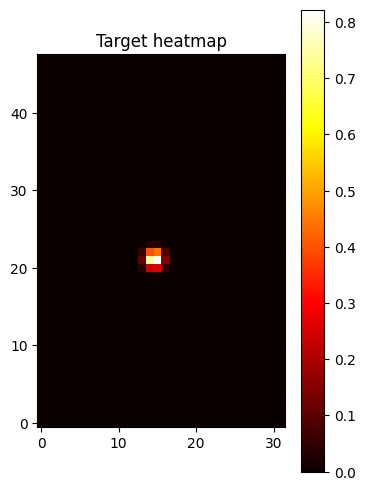

xy: [[2.2537217 3.2397695]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
mask: [1. 0. 0. 0.]


In [254]:
import matplotlib.pyplot as plt

i =2
plt.figure(figsize=(4, 6))
plt.imshow(y_heat_train[i, :, :, 0], cmap="hot", origin="lower")
plt.title("Target heatmap")
plt.colorbar()
plt.show()

print("xy:", y_xy_train[i])
print("mask:", y_mask_train[i])

BUILD THE MODEL

In [255]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def fire_module(x, squeeze_filters, expand_filters, name=None):
    s = layers.Conv2D(
        squeeze_filters, (1, 1),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_squeeze"
    )(x)

    e1 = layers.Conv2D(
        expand_filters, (1, 1),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_expand1x1"
    )(s)

    e3 = layers.Conv2D(
        expand_filters, (3, 3),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_expand3x3"
    )(s)

    x = layers.Concatenate(name=None if name is None else f"{name}_concat")([e1, e3])
    return x

In [256]:
len(FINAL_SELECTED_CHANNELS)

2

In [272]:
def build_squeezenet_heatmap(input_shape=(16, 120, 3), heatmap_h=24, heatmap_w=16):
    inputs = keras.Input(shape=input_shape, name="radar_input")

    # Stem
    x = layers.Conv2D(32, (3, 5), strides=(1, 1), padding="same", activation="relu", name="stem_conv")(inputs)
    x = layers.MaxPooling2D((1, 2), name="stem_pool")(x)   # (8, 60, 32)

    # Fire backbone
    x = fire_module(x, squeeze_filters=16, expand_filters=32, name="fire2")
    x = fire_module(x, squeeze_filters=16, expand_filters=32, name="fire3")
    x = layers.MaxPooling2D((2, 2), name="pool3")(x)       # (4, 30, ...)

    x = fire_module(x, squeeze_filters=24, expand_filters=48, name="fire4")
    x = fire_module(x, squeeze_filters=24, expand_filters=48, name="fire5")
    x = layers.MaxPooling2D((2, 2), name="pool5")(x)       # (2, 15, ...)

    x = fire_module(x, squeeze_filters=32, expand_filters=64, name="fire6")
    x = fire_module(x, squeeze_filters=32, expand_filters=64, name="fire7")

    # Light decoder
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="dec_conv1")(x)

    x = layers.UpSampling2D(size=(2, 2), name="up1")(x)    # (4, 30, 64)
    x = layers.Conv2D(48, (3, 3), padding="same", activation="relu", name="dec_conv2")(x)

    x = layers.UpSampling2D(size=(2, 2), name="up2")(x)    # (8, 60, 48)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="dec_conv3")(x)

    # Resize directly to target heatmap size
    x = layers.Resizing(heatmap_h, heatmap_w, interpolation="bilinear", name="resize_to_heatmap")(x)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid", padding="same", name="heatmap")(x)

    model = keras.Model(inputs, outputs, name="radar_squeezenet_heatmap")
    return model

In [273]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def conv_block(x, filters, kernel=(3, 3), name=None):
    x = layers.Conv2D(filters, kernel, padding="same", use_bias=False,
                      name=None if name is None else f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn1")(x)
    x = layers.Activation("relu", name=None if name is None else f"{name}_relu1")(x)

    x = layers.Conv2D(filters, kernel, padding="same", use_bias=False,
                      name=None if name is None else f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn2")(x)
    x = layers.Activation("relu", name=None if name is None else f"{name}_relu2")(x)

    return x


def fire_module(x, squeeze_filters, expand_filters, name=None):
    s = layers.Conv2D(
        squeeze_filters, (1, 1),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_squeeze"
    )(x)

    e1 = layers.Conv2D(
        expand_filters, (1, 1),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_expand1x1"
    )(s)

    e3 = layers.Conv2D(
        expand_filters, (3, 3),
        activation="relu",
        padding="same",
        name=None if name is None else f"{name}_expand3x3"
    )(s)

    return layers.Concatenate(name=None if name is None else f"{name}_concat")([e1, e3])


def build_stronger_squeezenet_heatmap(
    input_shape=(16, 120, 3),
    heatmap_h=48,
    heatmap_w=32
):
    inputs = keras.Input(shape=input_shape, name="radar_input")

    # Stronger input stem
    x0 = conv_block(inputs, 32, kernel=(3, 5), name="stem")      # (T, B, 32)

    # Encoder level 1
    x1 = layers.MaxPooling2D((1, 2), name="pool1")(x0)           # keep time, reduce bins
    x1 = fire_module(x1, 16, 32, name="fire1")
    x1 = fire_module(x1, 16, 32, name="fire2")                  # skip 1

    # Encoder level 2
    x2 = layers.MaxPooling2D((2, 2), name="pool2")(x1)
    x2 = fire_module(x2, 24, 48, name="fire3")
    x2 = fire_module(x2, 24, 48, name="fire4")                  # skip 2

    # Encoder level 3
    x3 = layers.MaxPooling2D((2, 2), name="pool3")(x2)
    x3 = fire_module(x3, 32, 64, name="fire5")
    x3 = fire_module(x3, 32, 64, name="fire6")

    # Bottleneck: more mapping power
    x = conv_block(x3, 128, kernel=(3, 3), name="bottleneck")
    x = layers.Dropout(0.25, name="bottleneck_dropout")(x)

    # Decoder level 1
    x = layers.UpSampling2D((2, 2), name="up1")(x)
    x = layers.Concatenate(name="skip2_concat")([x, x2])
    x = conv_block(x, 96, kernel=(3, 3), name="dec1")

    # Decoder level 2
    x = layers.UpSampling2D((2, 2), name="up2")(x)
    x = layers.Concatenate(name="skip1_concat")([x, x1])
    x = conv_block(x, 64, kernel=(3, 3), name="dec2")

    # Decoder level 3
    x = layers.UpSampling2D((1, 2), name="up3")(x)
    x = layers.Concatenate(name="skip0_concat")([x, x0])
    x = conv_block(x, 48, kernel=(3, 3), name="dec3")

    # Resize to room heatmap
    x = layers.Resizing(
        heatmap_h,
        heatmap_w,
        interpolation="bilinear",
        name="resize_to_heatmap"
    )(x)

    # Stronger heatmap head
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="head_conv1")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="head_conv2")(x)
    x = layers.Conv2D(16, (3, 3), padding="same", activation="relu", name="head_conv3")(x)

    outputs = layers.Conv2D(
        1,
        (1, 1),
        activation="sigmoid",
        padding="same",
        name="heatmap"
    )(x)

    model = keras.Model(inputs, outputs, name="stronger_radar_squeezenet_heatmap")
    return model

In [274]:
#model = build_squeezenet_heatmap(input_shape=(SEQ_LEN, BIN_END - BIN_START, 4), heatmap_h=96, heatmap_w=64)
model = build_stronger_squeezenet_heatmap(
    input_shape=X_train.shape[1:],
    heatmap_h=48,
    heatmap_w=32
)

model.summary()

Model: "stronger_radar_squeezenet_heatmap"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ radar_input         │ (None, 16, 120,   │          0 │ -                 │
│ (InputLayer)        │ 18)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv1 (Conv2D) │ (None, 16, 120,   │      8,640 │ radar_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn1            │ (None, 16, 120,   │        128 │ stem_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu1          │ (None, 16, 120,   │          0 │ stem_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv2 (Conv2D) │ (None, 16, 120,   │     15,360 │ stem_relu1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn2            │ (None, 16, 120,   │        128 │ stem_conv2[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu2          │ (None, 16, 120,   │          0 │ stem_bn2[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 60,    │          0 │ stem_relu2[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire1_squeeze       │ (None, 16, 60,    │        528 │ pool1[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire1_expand1x1     │ (None, 16, 60,    │        544 │ fire1_squeeze[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire1_expand3x3     │ (None, 16, 60,    │      4,640 │ fire1_squeeze[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire1_concat        │ (None, 16, 60,    │          0 │ fire1_expand1x1[… │
│ (Concatenate)       │ 64)               │            │ fire1_expand3x3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_squeeze       │ (None, 16, 60,    │      1,040 │ fire1_concat[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand1x1     │ (None, 16, 60,    │        544 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_expand3x3     │ (None, 16, 60,    │      4,640 │ fire2_squeeze[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_concat        │ (None, 16, 60,    │          0 │ fire2_expand1x1[… │
│ (Concatenate)       │ 64)               │            │ fire2_expand3x3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 30, 64) │          0 │ fire2_concat[0][

 Total params: 927,889 (3.54 MB)

 Trainable params: 926,417 (3.53 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [275]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
        w = tf.where(tf.equal(y_true, 1.0), alpha, 1.0 - alpha)

        return -tf.reduce_mean(w * tf.pow(1.0 - pt, gamma) * tf.math.log(pt))
    return loss

In [276]:
import tensorflow as tf

def heatmap_centroid_mae(y_true, y_pred):
    """
    Approximate XY error by comparing centroids of heatmaps
    """
    eps = 1e-6

    # flatten spatial dims
    H = tf.shape(y_true)[1]
    W = tf.shape(y_true)[2]

    # create coordinate grids
    ys = tf.linspace(0.0, 1.0, H)
    xs = tf.linspace(0.0, 1.0, W)
    yy, xx = tf.meshgrid(ys, xs, indexing="ij")  # (H, W)

    yy = tf.reshape(yy, (1, H, W, 1))
    xx = tf.reshape(xx, (1, H, W, 1))

    # normalize heatmaps
    y_true_sum = tf.reduce_sum(y_true, axis=[1,2,3], keepdims=True) + eps
    y_pred_sum = tf.reduce_sum(y_pred, axis=[1,2,3], keepdims=True) + eps

    y_true_norm = y_true / y_true_sum
    y_pred_norm = y_pred / y_pred_sum

    # compute centroids
    true_x = tf.reduce_sum(y_true_norm * xx, axis=[1,2,3])
    true_y = tf.reduce_sum(y_true_norm * yy, axis=[1,2,3])

    pred_x = tf.reduce_sum(y_pred_norm * xx, axis=[1,2,3])
    pred_y = tf.reduce_sum(y_pred_norm * yy, axis=[1,2,3])

    # L2 distance
    dist = tf.sqrt((true_x - pred_x)**2 + (true_y - pred_y)**2)

    return tf.reduce_mean(dist)

In [277]:
import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])

    dice = (2.0 * intersection + smooth) / (denom + smooth)
    return 1.0 - tf.reduce_mean(dice)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    dloss = dice_loss(y_true, y_pred)

    return bce + dloss

In [278]:
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",metrics=[heatmap_centroid_mae])
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    X_train,
    y_heat_train,
    validation_data=(X_test, y_heat_test),
    epochs=30,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 60ms/step - heatmap_centroid_mae: 0.1592 - loss: 0.0161 - val_heatmap_centroid_mae: 0.1888 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - heatmap_centroid_mae: 0.0989 - loss: 0.0102 - val_heatmap_centroid_mae: 0.1010 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - heatmap_centroid_mae: 0.0791 - loss: 0.0094 - val_heatmap_centroid_mae: 0.1110 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - heatmap_centroid_mae: 0.0667 - loss: 0.0088 - val_heatmap_centroid_mae: 0.0770 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - heatmap_centroid_mae: 0.0584 - loss: 0.0084 - val_heatmap_centroid_mae: 0.1311 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - heatmap_centroid_mae: 0.0500 - loss: 0.0080 - val_heatmap

In [279]:
def decode_predictions(pred_vec, occ_threshold=0.8):
    occ_logits = pred_vec[:4]
    xy = pred_vec[4:].reshape(4, 2)

    occ_prob = 1 / (1 + np.exp(-occ_logits))
    valid = occ_prob >= occ_threshold

    pts = []
    for i in range(4):
        if valid[i]:
            x = float(np.clip(xy[i, 0], 0.0, 4.8))
            y = float(np.clip(xy[i, 1], 0.0, 7.2))
            pts.append([x, y])

    return pts, occ_prob, xy

In [280]:
import numpy as np
import matplotlib.pyplot as plt

def show_heatmap_predictions_batch(
    model,
    X,
    y_heat,
    y_xy,
    y_mask,
    num_samples=10,
    start_idx=None,
    random=True,
    seed=42
):
    rng = np.random.default_rng(seed)

    if random:
        idxs = rng.choice(len(X), size=num_samples, replace=False)
    else:
        if start_idx is None:
            start_idx = 0
        idxs = list(range(start_idx, start_idx + num_samples))

    # Batch prediction (FAST)
    preds = model.predict(X[idxs], verbose=0)

    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 3 * num_samples))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(idxs):
        pred = preds[i, :, :, 0]
        gt   = y_heat[idx, :, :, 0]

        axes[i, 0].imshow(gt, cmap="hot", origin="lower")
        axes[i, 0].set_title(f"GT #{idx}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(pred, cmap="hot", origin="lower")
        axes[i, 1].set_title(f"Pred #{idx}")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

    # Optional: print info
    for idx in idxs:
        print("=" * 40)
        print(f"Sample {idx}")
        print("GT xy:\n", y_xy[idx])
        print("GT mask:", y_mask[idx])

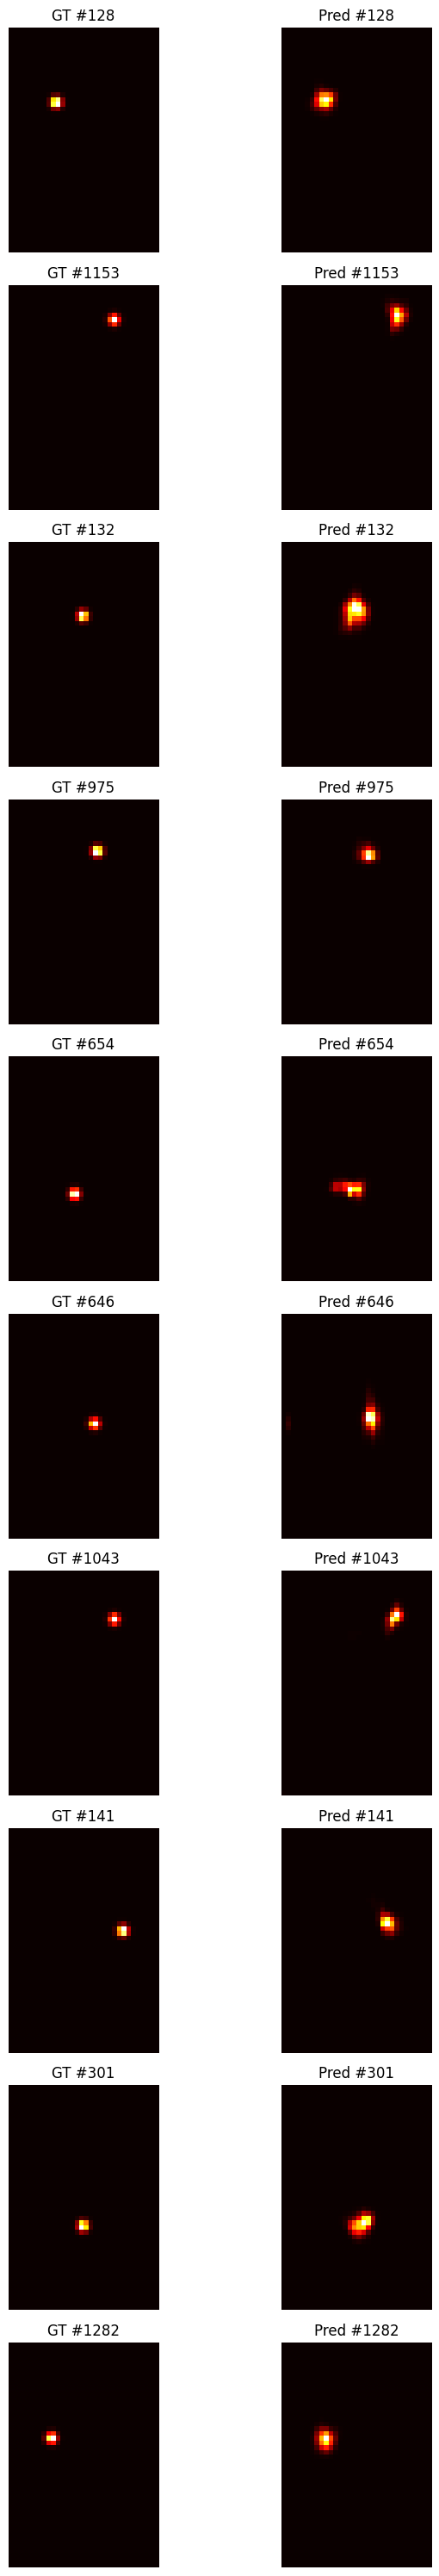

Sample 128
GT xy:
 [[1.4900916 4.8148413]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 1153
GT xy:
 [[3.3914728 6.1247797]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 132
GT xy:
 [[2.3629346 4.8418384]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 975
GT xy:
 [[2.8468263 5.5737333]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 654
GT xy:
 [[2.097529 2.76254 ]
 [0.       0.      ]
 [0.       0.      ]
 [0.       0.      ]]
GT mask: [1. 0. 0. 0.]
Sample 646
GT xy:
 [[2.7484882 3.6711419]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 1043
GT xy:
 [[3.4007611 5.6703134]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample 141
GT xy:
 [[3.679058  3.9180562]
 [0.        0.     

In [281]:
show_heatmap_predictions_batch(
    model,
    X_test,
    y_heat_test,
    y_xy_test,
    y_mask_test,
    num_samples=10,
    random=True
)

In [282]:
def heatmap_to_points(
    heatmap,
    threshold=0.2,
    max_people=4,
    room_x=4.8,
    room_y=7.2,
    single_person=False   # 👈 NEW FLAG
):
    """
    heatmap: (H, W)
    returns: list of [x, y]
    """

    H, W = heatmap.shape
    hm = heatmap.copy()

    points = []

    # =========================
    # ✅ SINGLE PERSON MODE
    # =========================
    if single_person:
        idx = np.argmax(hm)
        score = hm.flat[idx]

        if score >= threshold:
            row, col = np.unravel_index(idx, hm.shape)

            x = (col / (W - 1)) * room_x
            y = (row / (H - 1)) * room_y

            return [[float(x), float(y)]]

        return []  # no detection

    # =========================
    # 👥 MULTI PERSON MODE
    # =========================
    for _ in range(max_people):
        idx = np.argmax(hm)
        score = hm.flat[idx]

        if score < threshold:
            break

        row, col = np.unravel_index(idx, hm.shape)

        x = (col / (W - 1)) * room_x
        y = (row / (H - 1)) * room_y
        points.append([float(x), float(y)])

        # non-max suppression
        r0 = max(0, row - 1)
        r1 = min(H, row + 2)
        c0 = max(0, col - 1)
        c1 = min(W, col + 2)
        hm[r0:r1, c0:c1] = 0.0

    return points

In [285]:
import numpy as np

rng = np.random.default_rng(42)

n = min(300, len(X_test))
random_idxs = rng.choice(len(X_test), size=n, replace=False)

x_errors = []
y_errors = []
dist_errors = []

for idx in random_idxs:
    pred_heat = model.predict(X_test[idx:idx+1], verbose=0)[0, :, :, 0]
    pred_points = heatmap_to_points(
        pred_heat,
        threshold=0.1,
        max_people=1,
        single_person=True
    )

    gt_points = y_xy_test[idx][y_mask_test[idx].astype(bool)]

    print("=" * 60)
    print("Sample index:", idx)
    print("Predicted points:", pred_points)
    print("GT xy:", y_xy_test[idx])
    print("GT mask:", y_mask_test[idx])

    if len(pred_points) > 0 and len(gt_points) > 0:
        pred = np.array(pred_points[0])
        gt = gt_points[0]

        dx = abs(pred[0] - gt[0])
        dy = abs(pred[1] - gt[1])
        dist = np.linalg.norm(pred - gt)

        x_errors.append(dx)
        y_errors.append(dy)
        dist_errors.append(dist)

# =========================
# Averages
# =========================
if len(x_errors) > 0:
    print("\n===== Average Errors =====")
    print("Avg X error:", np.mean(x_errors))
    print("Avg Y error:", np.mean(y_errors))
    print("Avg distance error:", np.mean(dist_errors))
else:
    print("\nNo valid predictions to compute error.")

Sample index: 623
Predicted points: [[2.0129032258064514, 6.434042553191489]]
GT xy: [[2.1012034 6.3630247]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample index: 1309
Predicted points: []
GT xy: [[3.4430845 4.839743 ]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample index: 1418
Predicted points: [[0.46451612903225803, 4.2893617021276595]]
GT xy: [[0.5133839 4.529887 ]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample index: 1482
Predicted points: [[0.6193548387096773, 4.748936170212766]]
GT xy: [[0.6490384 4.6832633]
 [0.        0.       ]
 [0.        0.       ]
 [0.        0.       ]]
GT mask: [1. 0. 0. 0.]
Sample index: 123
Predicted points: [[0.7741935483870968, 5.361702127659575]]
GT xy: [[0.75354326 5.2377687 ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]
GT mask: [1. 0. 0. 0.]
Sample index: 844
Pre

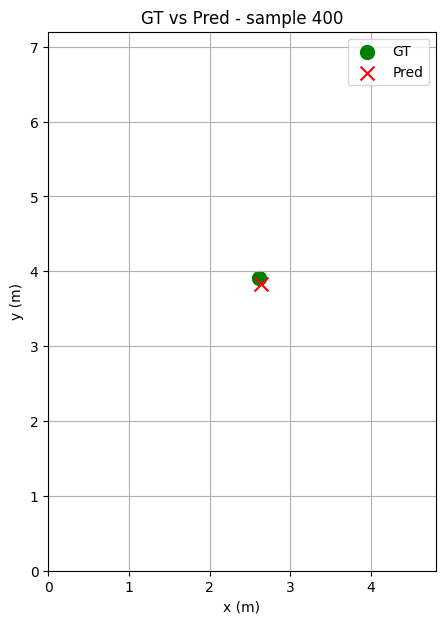

In [286]:
def get_gt_points(xy, mask):
    valid = mask.astype(bool)
    return xy[valid]

def plot_gt_vs_pred_points(model, X, y_xy, y_mask, idx=500, threshold=0.3):
    pred_heat = model.predict(X[idx:idx+1], verbose=0)[0, :, :, 0]
    pred_points = heatmap_to_points(pred_heat, threshold=threshold, max_people=1)

    gt_points = get_gt_points(y_xy[idx], y_mask[idx])

    plt.figure(figsize=(5, 7))

    if len(gt_points) > 0:
        plt.scatter(gt_points[:, 0], gt_points[:, 1], c="green", s=100, label="GT")

    if len(pred_points) > 0:
        pred_points = np.array(pred_points)
        plt.scatter(pred_points[:, 0], pred_points[:, 1], c="red", marker="x", s=100, label="Pred")

    plt.xlim(0, ROOM_X)
    plt.ylim(0, ROOM_Y)
    plt.grid()
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"GT vs Pred - sample {idx}")
    plt.legend()
    plt.show()
plot_gt_vs_pred_points(model, X_test, y_xy_test, y_mask_test, idx=400 , threshold=0.1)

In [287]:
import numpy as np
import matplotlib.pyplot as plt

def plot_global_gt_vs_pred_paired(
    model,
    X,
    y_xy,
    y_mask,
    num_samples=30,
    threshold=0.1,
    max_people=1,
    seed=42,
    single_person=False
):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=min(num_samples, len(X)), replace=False)

    pred_heatmaps = model.predict(X[idxs], verbose=0)

    plt.figure(figsize=(7, 9))

    for k, idx in enumerate(idxs):
        pred_heat = pred_heatmaps[k, :, :, 0]
        pred_points = heatmap_to_points(
            pred_heat,
            threshold=threshold,
            max_people=max_people,
            single_person=True
        )

        gt_points = y_xy[idx][y_mask[idx].astype(bool)]

        if len(gt_points) == 0 or len(pred_points) == 0:
            continue

        gt = gt_points[0]
        pred = np.array(pred_points[0])

        # GT point
        plt.scatter(gt[0], gt[1], c="green", s=80)
        plt.text(gt[0], gt[1], f"{k}", fontsize=9, color="green")

        # Pred point
        plt.scatter(pred[0], pred[1], c="red", marker="x", s=90)
        plt.text(pred[0], pred[1], f"{k}", fontsize=9, color="red")

        # Pairing line
        plt.plot(
            [gt[0], pred[0]],
            [gt[1], pred[1]],
            linestyle="--",
            linewidth=1,
            alpha=0.6
        )

    plt.scatter([], [], c="green", s=80, label="GT")
    plt.scatter([], [], c="red", marker="x", s=90, label="Pred")
    plt.plot([], [], linestyle="--", color="gray", label="GT → Pred")

    plt.xlim(0, ROOM_X)
    plt.ylim(0, ROOM_Y)
    plt.grid()
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"Paired GT vs Pred ({len(idxs)} samples)")
    plt.legend()
    plt.show()

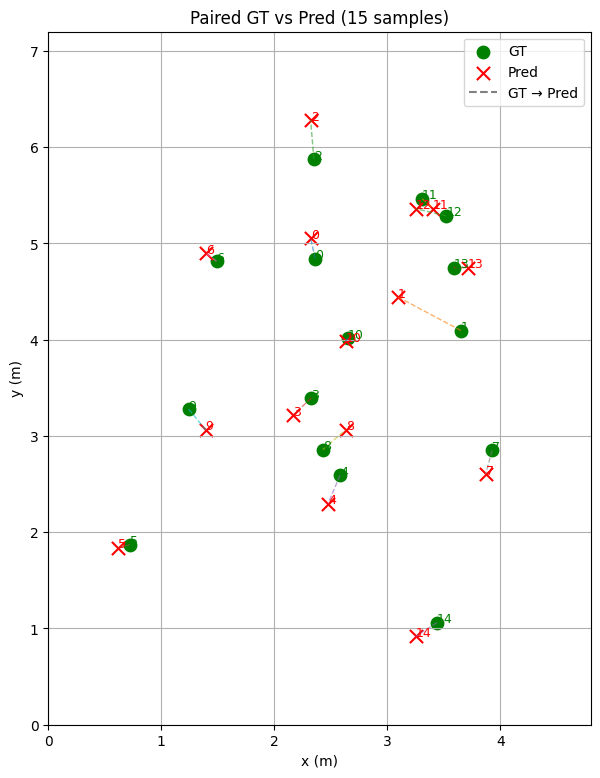

In [288]:
plot_global_gt_vs_pred_paired(
    model,
    X_test,
    y_xy_test,
    y_mask_test,
    num_samples=15,
    threshold=0.00,
    max_people=1,
    single_person=True
)

In [289]:
import numpy as np

def evaluate_distance_error_full_dataset(
    model,
    X_test,
    y_xy_test,
    y_mask_test,
    threshold=0.1
):
    dist_errors = []
    misses = 0
    total = len(X_test)

    # 🔥 Batch prediction (fast)
    pred_heatmaps = model.predict(X_test, verbose=0)

    for i in range(total):
        pred_heat = pred_heatmaps[i, :, :, 0]

        pred_points = heatmap_to_points(
            pred_heat,
            threshold=threshold,
            max_people=1,
            single_person=True
        )

        gt_points = y_xy_test[i][y_mask_test[i].astype(bool)]

        # only 1-person case assumed
        if len(gt_points) == 0:
            continue

        gt = gt_points[0]

        if len(pred_points) == 0:
            misses += 1
            continue

        pred = np.array(pred_points[0])

        dist = np.linalg.norm(pred - gt)
        dist_errors.append(dist)

    # =========================
    # Results
    # =========================
    if len(dist_errors) > 0:
        avg_dist = np.mean(dist_errors)
    else:
        avg_dist = None

    print("\n===== FULL TEST SET METRICS =====")
    print("Total samples        :", total)
    print("Valid detections     :", len(dist_errors))
    print("Missed detections    :", misses)
    print("Detection rate       :", len(dist_errors) / total)

    if avg_dist is not None:
        print("Avg distance error   :", avg_dist)
    else:
        print("Avg distance error   : N/A")

    return avg_dist, dist_errors

In [292]:
avg_dist, dist_errors = evaluate_distance_error_full_dataset(
    model,
    X_test,
    y_xy_test,
    y_mask_test,
    threshold=0.1
)


===== FULL TEST SET METRICS =====
Total samples        : 1498
Valid detections     : 1366
Missed detections    : 132
Detection rate       : 0.9118825100133512
Avg distance error   : 0.2660988672288602
